# Models trained on data after Balancing and Sampling

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/04 16:30:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/04 16:30:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2025-11-04 16:31:00,370 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/11/04 16:31:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-11-04 16:31:02,518 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-11-04 16:31:04,554 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-11-04 16:31:04,554 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-11-04 16:31

# Load Data

In [14]:
df_2018 = spark.read.format("parquet").load( "df_1102_w_adherence_features_stage56.parquet")
df_og = df_2018.toPandas()
df_og.shape,df_og.columns

((7696, 97),
 Index(['ENROLID', 'INCOME_LEVEL', '2017Q1_ckd_cost', '2017Q1_ckd_claims',
        '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost',
        '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost',
        '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage',
        '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost',
        '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims',
        '2017Q3_max_ckd_stage', '2017Q3_direct_ckd_cost',
        '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost',
        '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage',
        '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost',
        '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017',
        'ckd_cost_trend_2017', 'ckd_cost_volatility_2017',
        'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017',
        'ckd_cost_deriv_Q3_Q4_2017', 'is_increasing_Q1_Q2_2017',
        'is_increasing_Q2_Q3_2017', 'is_increasing_Q3_Q4_20

In [4]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)

# Correctly import your custom modules
import evaluate_model_by_risk_bin

# Then reload them
importlib.reload(evaluate_model_by_risk_bin)

<module 'evaluate_model_by_risk_bin' from '/Users/cat2510/my_projects/evaluate_model_by_risk_bin.py'>

# Feature groups, define high cost and train-test-split

In [16]:
for c in df_og.columns:
    if df_og[c].isna().any():
        print(c)

df_og.drop(["first_ckd_date","first_nephrology_date"],axis=1,inplace=True)

first_ckd_date
lab_monitoring_intensity
first_nephrology_date


In [17]:
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'cost_pattern_2017', 'cost_stability_2017', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
stage cols:  ['2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'is_increasing_Q1_Q2_2017', 'is_increasing_Q2_Q3_2017', 'is_increasing_Q3_Q4_2017', 'total_increasing_quarters_2017', 'is_consistently_increasing_2017', 'avg_quar

In [18]:
def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
   # cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1

    # for stages 5-6:
    cost_stratum[(df['highcost_gt_200000'] == 1) & (df['highcost_gt_300000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_300000'] == 1) & (df['highcost_gt_400000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_400000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))
cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)

# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=123)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))


cost_stratum_2018
0    6398
1     708
2     304
3     286
Name: count, dtype: int64
High corr features dropped from prediction columns:  []
(5387, 96) (2309, 96)
Feature cols: 79


In [ ]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned

target_col = "highcost_gt_300000"

param_grid = {
            "max_depth": [5, 7, 9],
            "minbucket": [50,100,120,150],#[100, 150,200,250],
            "cp": [0.00001,5e-4, 0.0001,5e-3, 0.001, 0.01, 0.1],#[5e-4, 1e-4, 1e-3,1e-5]
        }
# After your pre-balancing step:
pipeline_results = train_stratifier_oct_tuned(
    df_prebalanced=train_pd,
    stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
    CAT_COLUMNS=CAT_COLUMNS,
    TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
    target=target_col

)

# Access results:
df_M1 = pipeline_results['df_with_leaves']
model = pipeline_results['model']
preprocessor = pipeline_results['preprocessor']
feature_names = pipeline_results['feature_names']

model

Using full dataset for tuning: 5,387 rows
Target distribution (tuning base):
  Class 0: 4,974 (92.3%)
  Class 1: 413 (7.7%)
Total parameter combinations before sampling: 48

[1/48] Evaluating params: {'max_depth': 5, 'minbucket': 100, 'cp': 0.0005}
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd

Fitted OptimalTreeClassifier:
  1) Predict: 0 (92.33%), [4974,413], 5387 points, error 0.07667

In [20]:
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct

X_test_M0 = evaluate_binary_oct(model,X_test,y_test,preprocessor,feature_names)

Test dataset for OCT application: 2,309 samples
✓ Feature names: ['INCOME_LEVEL_1', 'INCOME_LEVEL_2', 'INCOME_LEVEL_3', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'lab_monitoring_intensity_Low', 'lab_monitoring_intensity_Minimal', 'lab_monitoring_intensity_Moderate', 'lab_monitoring_intensity_None', '2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage', 'is_consistently_decreasing_2017', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'THRCLS_52', 'THRCLS_51', 'THRCLS_53', 'THRCLS_54', 'THRCLS_181', 'THRCLS_241', 'THRCLS_120', 'THRCLS_224'

[ Warning: The type of y (Any) does not match the original target type (Int64)


# Matching

In [21]:
import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)
from balancing_functions.optimal_match_lexicographic import LexicographicCaseControlResampler
def create_lexicographic_undersampled_data(pipeline_results, target_col, 
                                         undersampling_ratio=5.0, 
                                         balance_tolerance=0.7, max_controls_per_case = 1,
                                         verbose=True):
    """
    Parameters:
    -----------
    balance_tolerance : float
        If majority_size - minority_size <= balance_tolerance * minority_size, 
        skip undersampling for this leaf
    pipeline_results : dict
        Results from your create_cost_strata_pipeline()
    target_col : str
        Target column (e.g., 'high_cost_2018')
    undersampling_ratio : float
        Target majority:minority ratio
    use_adaptive_filtering : bool
        Whether to use adaptive filtering fallback
    verbose : bool
        Print progress information
    
    Returns:
    --------
    pd.DataFrame : Undersampled dataset
    """
    
    # Extract data from pipeline results
    df_with_leaves = pipeline_results['df_with_leaves']
    feature_cols = pipeline_results['stratification_cols']
    
    # Initialize lexicographic matcher
    matcher = LexicographicCaseControlResampler(
        matching_method="ortools",
        random_state=42,
        binary_group=target_col,
        uid_col="ENROLID"  
    )
    
    print(f"=== LEXICOGRAPHIC OPTIMIZATION UNDERSAMPLING ===")
    print(f"Original dataset: {len(df_with_leaves):,} samples")
    
    # Process each leaf
    unique_leaves = df_with_leaves['leaf_assignment'].unique()
    print(f"Processing {len(unique_leaves)} OCT leaves...")
    
    undersampled_parts = []
    
    for leaf_id in sorted(unique_leaves):
        leaf_df = df_with_leaves[
            df_with_leaves['leaf_assignment'] == leaf_id
        ].copy()
            
        # Skip small leaves
        if len(leaf_df) < 30:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (too small: {len(leaf_df)} samples)")
            continue
        
        # Check class distribution
        class_counts = leaf_df[target_col].value_counts()
        if len(class_counts) < 2:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (single class)")
            continue
            
        majority_class = class_counts.index[0]
        minority_class = class_counts.index[1] 
        n_majority = class_counts[majority_class]
        n_minority = class_counts[minority_class]

        if n_majority <= 300:
            disable_lexicographic = True
            undersampling_ratio = 1

        else:
            disable_lexicographic = False
        
        # NEW: Check if leaf is already nearly balanced
        imbalance = n_majority - n_minority
        balance_threshold = balance_tolerance * n_minority
        
        if imbalance <= balance_threshold:
            if verbose:
                print(f"Leaf {leaf_id}: Already balanced (n_maj - n_min: {imbalance} ≤ 0.9*n_min {balance_threshold:.1f}), keeping as-is")
                print(f"  Counts: {n_majority} majority, {n_minority} minority")
            undersampled_parts.append(leaf_df)
            continue
        
        # Calculate target
        target_majority = n_minority * undersampling_ratio
        if target_majority >= n_majority:
            undersampled_parts.append(leaf_df)
            print(f"Skipping undersampling: Target majority value larger than existing majority samples")
            print(f"  Counts: {n_majority} majority, {n_minority} minority")

            continue
        
        # Separate classes
        majority_df = leaf_df[leaf_df[target_col] == majority_class].copy()
        minority_df = leaf_df[leaf_df[target_col] == minority_class].copy()
        
        if verbose:
            print(f"\nLeaf {leaf_id}: {n_majority} majority → {target_majority} (keeping {n_minority} minority)")
        
        try:
        
            matched_result = matcher.ortools_optimization_matching(
                dfA=minority_df,
                dfB=majority_df,
                target_controls=target_majority, 
                target_cases=n_minority,
                exclude_cols_matching=['leaf_assignment', 'cost_stratum']+COST_COLUMNS,
                verbose=verbose,
                max_controls_per_case=max_controls_per_case, 
                top_k_factor=700,
                similarity_threshold=0.5,
                disable_lexicographic=disable_lexicographic
            )
        
            undersampled_parts.append(matched_result)
            
            if verbose:
                final_counts = matched_result[target_col].value_counts()
                print(f"  Result: {dict(final_counts)}")
                
        except Exception as e:
            if verbose:
                print(f"  Optimization failed: {e}")
                print(f"  Keeping leaf as-is due to optimization failure")
            undersampled_parts.append(leaf_df)  # Fallback to original
    
    # Combine results
    if undersampled_parts:
        final_result = pd.concat(undersampled_parts, ignore_index=True)
        
        print(f"\n=== FINAL RESULTS ===")
        print(f"Original: {len(df_with_leaves):,} samples")
        print(f"Undersampled: {len(final_result):,} samples")
        print(f"Reduction: {(1-len(final_result)/len(df_with_leaves))*100:.1f}%")
        
        original_dist = df_with_leaves[target_col].value_counts()
        final_dist = final_result[target_col].value_counts()
        print(f"Class distribution:")
        for cls in original_dist.index:
            print(f"  Class {cls}: {original_dist[cls]:,} → {final_dist.get(cls, 0):,}")
        
        return final_result
    else:
        print("Warning: No leaves processed successfully")
        return pd.DataFrame()


undersampled_training_data = create_lexicographic_undersampled_data(
    pipeline_results=pipeline_results,
    target_col=target_col,
    undersampling_ratio=2, max_controls_per_case = 2, # TODO change to 2,3,4,5
    verbose=True
)
print(f"Final training data size: {len(undersampled_training_data):,}")

=== LEXICOGRAPHIC OPTIMIZATION UNDERSAMPLING ===
Original dataset: 5,387 samples
Processing 1 OCT leaves...

Leaf 1: 4974 majority → 826 (keeping 413 minority)
>>> Distance computation will use 43 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
13 Numeric features (normalized): ['2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'util_2017', 'total_lab_tests', 'nephrology_visit_count', 'cost_stratum_2018', 'predicted_cost_stratum']
25 Binary features (unchanged): ['is_consistently_decreasing_2017', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'THRCLS_52', 'THRCLS_51', 'THRCLS_

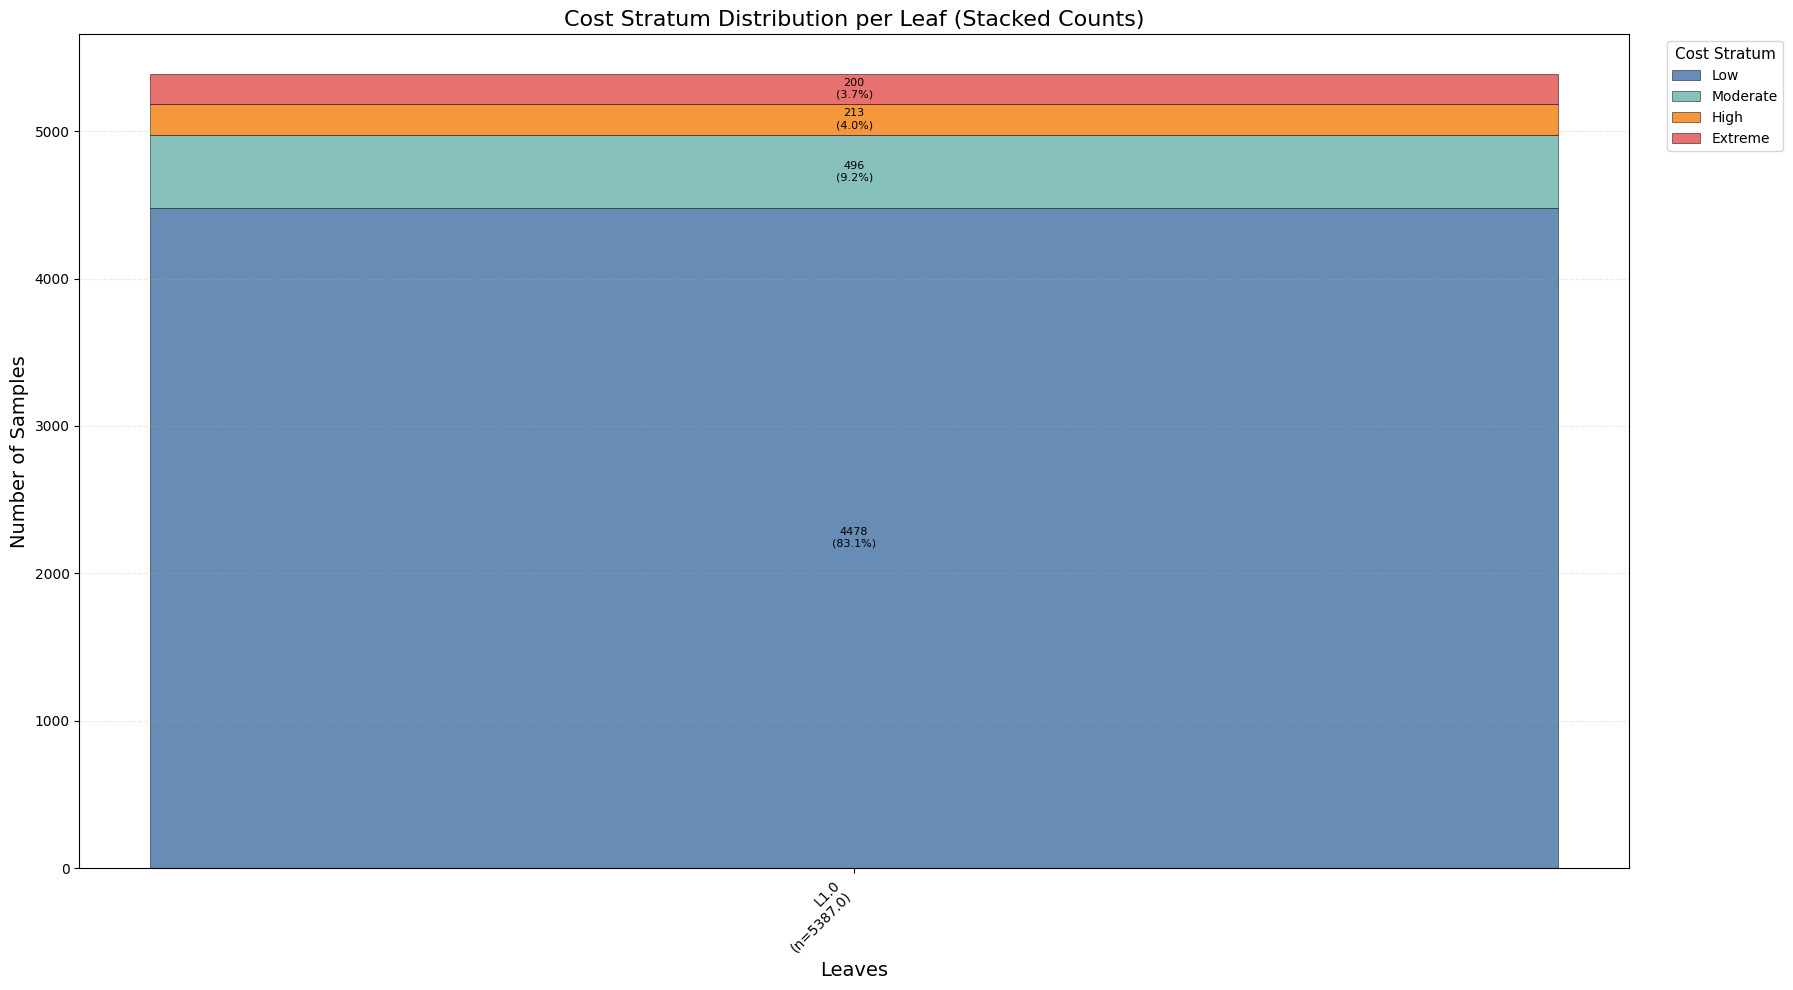


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 4478 (83.1%)
  Stratum 1 (Moderate): 496 (9.2%)
  Stratum 2 (High): 213 (4.0%)
  Stratum 3 (Extreme): 200 (3.7%)

Dominant stratum frequency among selected leaves:
  Stratum 0 (Low): 1 leaves (100.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.831      1.000
       1 Moderate        0.092      0.000
       2     High        0.040      0.000
       3  Extreme        0.037      0.000


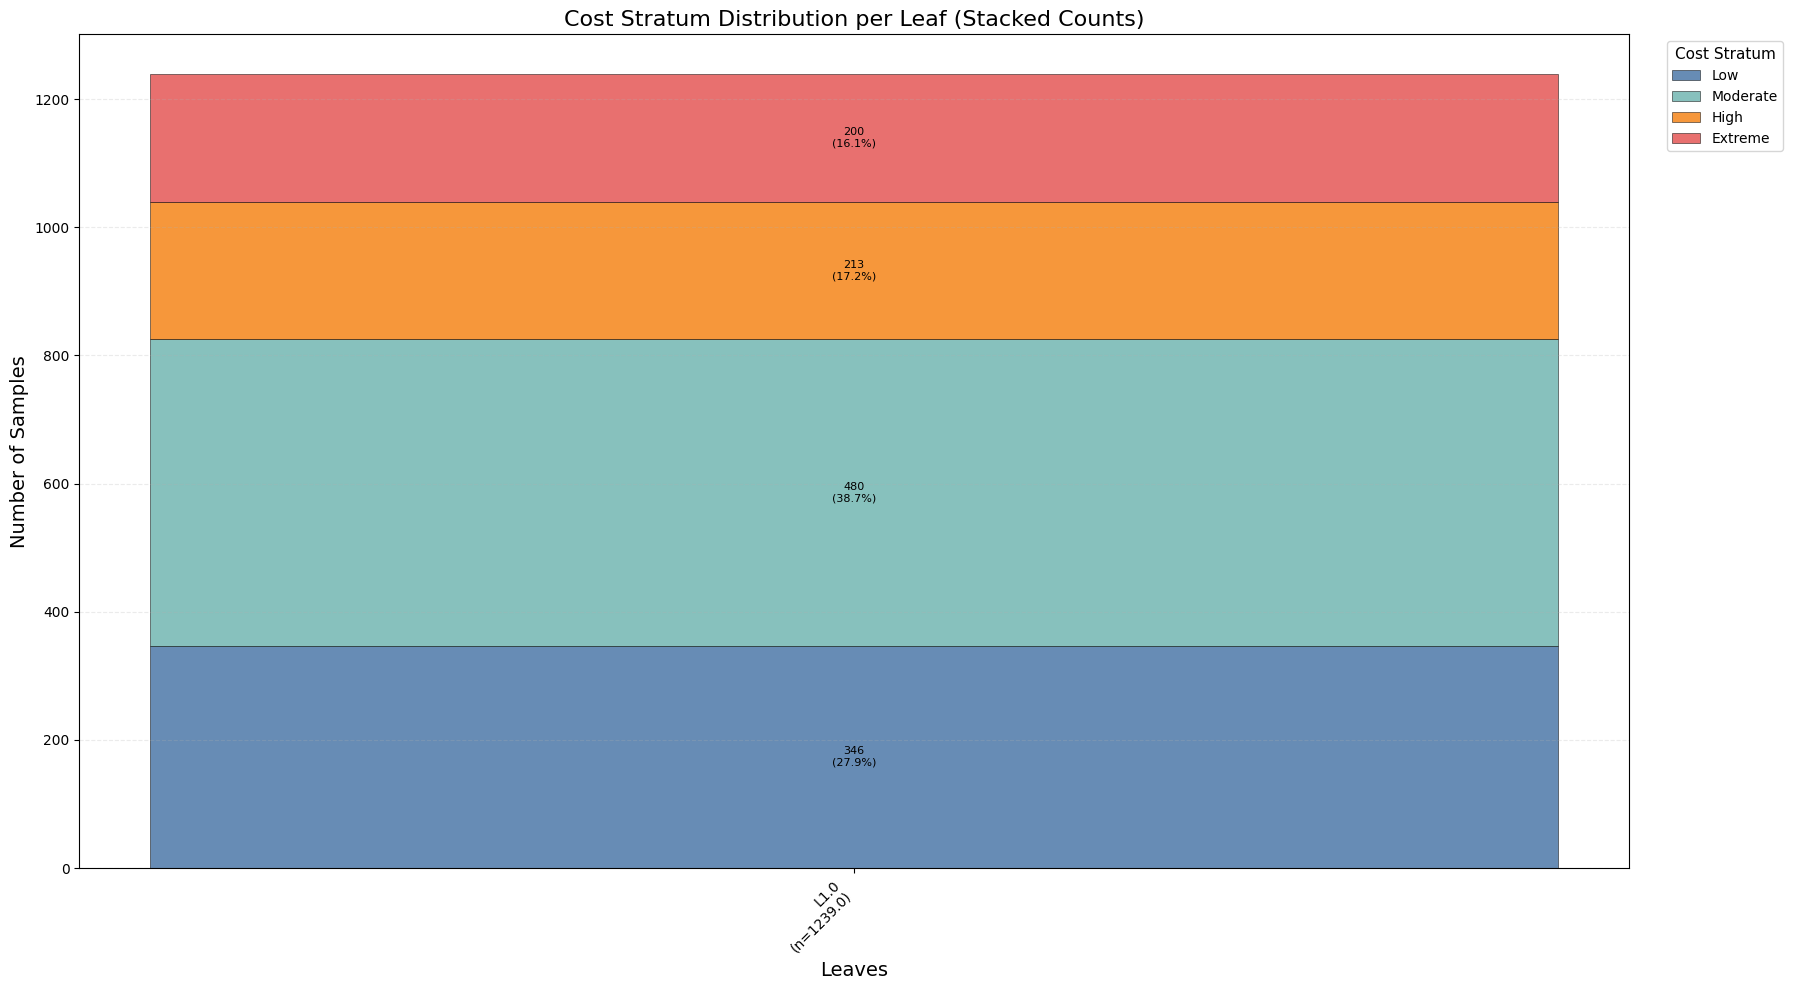


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 346 (27.9%)
  Stratum 1 (Moderate): 480 (38.7%)
  Stratum 2 (High): 213 (17.2%)
  Stratum 3 (Extreme): 200 (16.1%)

Dominant stratum frequency among selected leaves:
  Stratum 1 (Moderate): 1 leaves (100.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.279      1.000
       1 Moderate        0.387      0.000
       2     High        0.172      0.000
       3  Extreme        0.161      0.000


In [22]:
import oct_leaf_analysis
importlib.reload(oct_leaf_analysis)
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    df_M1,
    strata_labels=labels,
    strata_colors=colors
)

leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    undersampled_training_data,
    strata_labels=labels,
    strata_colors=colors
)


# Model Comparisons

In [23]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)
from model_IAI import finetune_oct
_,_,undersampled_train,undersampled_val = model_pipeline.train_test_split_enrol(undersampled_training_data, target_col = "cost_stratum_2018",test_size=0.3,verbose=False)
X_train_undersampled = undersampled_train[feature_cols]
y_train_undersampled = undersampled_train[target_col]
X_val_undersampled = undersampled_val[feature_cols]
y_val_undersampled = undersampled_val[target_col]
print(X_train_undersampled.shape)

minbuckets_M2=[50,100,120,150]
cps_M2=[0.00001,5e-4, 0.0001,5e-3, 0.001, 0.01, 0.1]
depths_M2=[5,7,9]
balanced_model, balanced_params, results_balanced ,preprocessor, feature_names = finetune_oct(
    X_train_undersampled, y_train_undersampled,X_val_undersampled, y_val_undersampled,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", balanced_params)
print("Balanced model: ")
evaluate_binary_oct(balanced_model,X_test,y_test,preprocessor,feature_names)

balanced_model



(867, 79)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'cost_pattern_2017', 'cost_stability_2017', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quart

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_direct_ckd_cost < 1.554
    2) Split: quarterly_range_2017 < -0.3368
      3) Predict: 0 (79.33%), [307,80], 387 points, error 0.2067
      4) Split: 2017Q4_ckd_cost < -0.2065
        5) Predict: 0 (76.81%), [106,32], 138 points, error 0.2319
        6) Split: total_ckd_cost_2017 < 0.5106
          7) Split: 2017Q1_procedure_ckd_cost < -0.1005
            8) Predict: 0 (72.92%), [105,39], 144 points, error 0.2708
            9) Predict: 1 (67.86%), [18,38], 56 points, error 0.3214
          10) Predict: 1 (62.65%), [31,52], 83 points, error 0.3735
    11) Predict: 1 (81.36%), [11,48], 59 points, error 0.1864

In [31]:
from imblearn.under_sampling import RandomUnderSampler

X = train_pd.drop(columns=[target_col])
y = train_pd[target_col]

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)


undersampled_rus = pd.concat([X_res, y_res], axis=1)
print(undersampled_rus['cost_stratum_2018'].value_counts())
_,_,rus_train,rus_val = model_pipeline.train_test_split_enrol(undersampled_rus, target_col = "cost_stratum_2018",test_size=0.3,verbose=False)
X_train_rus = rus_train[feature_cols]
y_train_rus = rus_train[target_col]
X_val_rus = rus_val[feature_cols]
y_val_rus = rus_val[target_col]
print(X_train_rus.shape)
rus_model, rus_params, results_rus, preprocessor, feature_names = finetune_oct(
    X_train_rus, y_train_rus,X_val_rus, y_val_rus,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", rus_params)
evaluate_binary_oct(rus_model,X_test,y_test,preprocessor,feature_names)

rus_model



cost_stratum_2018
0    368
2    213
3    200
1     45
Name: count, dtype: int64
(578, 79)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'cost_pattern_2017', 'cost_stability_2017', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', '

Fitted OptimalTreeClassifier:
  1) Split: annual_cost17 < 0.183
    2) Split: ckd_cost_trend_2017 < -0.1778
      3) Predict: 0 (81.13%), [215,50], 265 points, error 0.1887
      4) Predict: 1 (68.83%), [48,106], 154 points, error 0.3117
    5) Predict: 1 (83.65%), [26,133], 159 points, error 0.1635

In [24]:
_,_,train_val_pd,val_pd = model_pipeline.train_test_split_enrol(train_pd, target_col = "cost_stratum_2018",test_size=0.3,verbose=False)
X_train_final = train_val_pd[feature_cols]
y_train_final = train_val_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]
print(X_train_final.shape)

# Logistic Regression for binary high-cost prediction
print("Training Logistic Regression model...")
log_pipeline = model_pipeline.get_logistic_pipeline(
    df=X_train_final,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, C=0.1, max_iter=1000,
)
log_pipeline.fit(X_train_final, y_train_final)  # Binary classification

# Random Forest for binary high-cost prediction
print("Training Random Forest model...")
rf_pipeline = model_pipeline.get_random_forest_pipeline(
    df=X_train_final ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
)
rf_pipeline.fit(X_train_final, y_train_final )  # Binary classification

# Gradient Boosting for binary high-cost prediction
print("Training Gradient Boosting model...")
gb_pipeline = model_pipeline.get_histgb_pipeline(
   df=X_train_final ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, balance_classes = True
)
gb_pipeline.fit(X_train_final, y_train_final)  # Binary classification


(3770, 79)
Training Logistic Regression model...
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'cost_pattern_2017', 'cost_stability_2017', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurt

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['INCOME_LEVEL',
                                                   'cost_pattern_2017',
                                                   'cost_stability_2017',
                                                   'AGEGRP', 'SEX', 'REGION',
                                                   'lab_monitoring_intensity']),
                                                 ('num', StandardScaler(),
                                                  ['2017Q1_ckd_cost',
                                                   '2017Q1_ckd_claims',
                                                   '2017Q1_direct_ckd_cost',
                                                   '201...
                                                   'total_ckd_cost_2017',
                                                   'ckd_cost_trend_2017',
                                                   'ckd_cost_volatility_2017',
                                                   'ckd_cost_deriv_Q1_Q2_2017',
                                                   'ckd_cost_deriv_Q2_Q3_2017',
                                                   'ckd_cost_deriv_Q3_Q4_2017',
                                                   'avg_quarterly_derivative_2017',
                                                   'quarterly_std_2017',
                                                   'quarterly_skewness_2017',
                                                   'quarterly_kurtosis_2017', ...])])),
                ('classifier',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                max_iter=200,
                                                random_state=42))])